<a href="https://colab.research.google.com/github/AnikKushwaha/AnikKushwaha/blob/master/Jobwork1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [92]:
!sudo apt-get update -qq
!sudo apt-get install -y -qq tesseract-ocr
!pip install -q transformers datasets evaluate accelerate \
                pytesseract easyocr opencv-python-headless pillow \
                spacy seqeval
!pip install -q "git+https://github.com/clovaai/donut.git" || true


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
  Preparing metadata (setup.py) ... done


In [9]:
!sudo apt-get install poppler-utils
!pip install pdf2image


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  poppler-utils
0 upgraded, 1 newly installed, 0 to remove and 47 not upgraded.
Need to get 186 kB of archives.
After this operation, 697 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 poppler-utils amd64 22.02.0-2ubuntu0.11 [186 kB]
Fetched 186 kB in 1s (180 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package poppler-utils.
(Reading database ... 125080

In [93]:
from pdf2image import convert_from_path
import os

pdf_files = ["invoice.pdf", "report.pdf", "resume.pdf"]
output_dir = "/content/pdf_images"
os.makedirs(output_dir, exist_ok=True)

for pdf in pdf_files:
    pages = convert_from_path(pdf, 300)
    for i, page in enumerate(pages):
        image_path = os.path.join(output_dir, f"{pdf}_page{i+1}.png")
        page.save(image_path, 'PNG')
        print("Saved:", image_path)

print("PDF conversion completed!")


Saved: /content/pdf_images/invoice.pdf_page1.png
Saved: /content/pdf_images/report.pdf_page1.png
Saved: /content/pdf_images/resume.pdf_page1.png
PDF conversion completed!


In [32]:
import pytesseract
from PIL import Image

for file in os.listdir(output_dir):
    if file.lower().endswith(".png"):
        img_path = os.path.join(output_dir, file)
        print("\n===== OCR for:", file, "=====")
        text = pytesseract.image_to_string(Image.open(img_path))
        print(text)



===== OCR for: invoice.pdf_page1.png =====
INVOICE

Company: ABC Pvt Ltd
Bill To: John Doe

Item Qty Price

Pen 10 $5

Total: $50


===== OCR for: invoice.pdf_1.png =====
INVOICE

Company: ABC Pvt Ltd
Bill To: John Doe

Item Qty Price

Pen 10 $5

Total: $50


===== OCR for: resume.pdf_1.png =====
RESUME

Name: Jane Smith

Skills: Python, ML, OCR
Experience: 2 years at XYZ Corp


===== OCR for: report.pdf_page1.png =====
PROJECT REPORT
Topic: Al Document Understanding

Summary: This project extracts data from documents


===== OCR for: resume.pdf_page1.png =====
RESUME

Name: Jane Smith

Skills: Python, ML, OCR
Experience: 2 years at XYZ Corp


===== OCR for: report.pdf_1.png =====
PROJECT REPORT
Topic: Al Document Understanding

Summary: This project extracts data from documents



In [94]:
import easyocr
import os
from pdf2image import convert_from_path

reader = easyocr.Reader(['en'])
pdf_files = ["invoice.pdf", "report.pdf", "resume.pdf"]

output_dir = "/content/pdf_images"
os.makedirs(output_dir, exist_ok=True)

ocr_results = []

for pdf in pdf_files:
    pages = convert_from_path(f"/content/{pdf}", 300)
    for i, page in enumerate(pages):
        image_path = os.path.join(output_dir, f"{pdf}_{i+1}.png")
        page.save(image_path, 'PNG')

        result = reader.readtext(image_path)

        ocr_results.append({
            "file_name": image_path,
            "label": pdf.split(".")[0],
            "ocr": result
        })

print(" OCR with bounding boxes completed!")


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


 OCR with bounding boxes completed!


In [95]:
layoutlm_data = []

def normalize_bbox(bbox, width, height):
    xs = [p[0] for p in bbox]
    ys = [p[1] for p in bbox]
    return [
        int(1000 * min(xs) / width),
        int(1000 * min(ys) / height),
        int(1000 * max(xs) / width),
        int(1000 * max(ys) / height)
    ]

for item in ocr_results:
    img = Image.open(item["file_name"])
    width, height = img.size

    words, boxes = [], []

    for bbox, text, _ in item["ocr"]:
        words.append(text)
        boxes.append(normalize_bbox(bbox, width, height))

    layoutlm_data.append({
        "image_path": item["file_name"],
        "words": words,
        "bbox": boxes,
        "label": item["label"]
    })

print(" Converted for LayoutLMv3 input format!")


 Converted for LayoutLMv3 input format!


In [96]:
layoutlm_data = []

def normalize_bbox(bbox, width, height):
    xs = [p[0] for p in bbox]
    ys = [p[1] for p in bbox]
    return [
        int(1000 * min(xs) / width),
        int(1000 * min(ys) / height),
        int(1000 * max(xs) / width),
        int(1000 * max(ys) / height)
    ]

for item in ocr_results:
    img = Image.open(item["file_name"])
    width, height = img.size

    words = []
    boxes = []

    for text, bbox, _ in item["ocr"]:
        if not isinstance(bbox, list) or len(bbox) != 4:
            continue

        if not all(isinstance(point, (list, tuple)) and len(point) == 2 for point in bbox):
            continue

        words.append(text)
        boxes.append(normalize_bbox(bbox, width, height))

    if words:
        layoutlm_data.append({
            "image_path": item["file_name"],
            "words": words,
            "bbox": boxes,
            "label": item["label"]
        })

print(" Converted for LayoutLMv3 input format after cleaning invalid OCR!")


 Converted for LayoutLMv3 input format after cleaning invalid OCR!


In [97]:
label2id = {"invoice": 0, "report": 1, "resume": 2}

for item in layoutlm_data:
    item["label_id"] = label2id[item["label"]]

print(" Label mapping done!")


 Label mapping done!


In [99]:
print("OCR results:", len(ocr_results))
print("LayoutLM data:", len(layoutlm_data))
print(ocr_results[:1])


OCR results: 3
LayoutLM data: 0
[{'file_name': '/content/pdf_images/invoice.pdf_1.png', 'label': 'invoice', 'ocr': [([[np.int32(201), np.int32(130)], [np.int32(417), np.int32(130)], [np.int32(417), np.int32(184)], [np.int32(201), np.int32(184)]], 'INVOICE', np.float64(0.9999250695082876)), ([[np.int32(198), np.int32(209)], [np.int32(729), np.int32(209)], [np.int32(729), np.int32(284)], [np.int32(198), np.int32(284)]], 'Company: ABC Pvt Ltd', np.float64(0.9857297450364225)), ([[np.int32(207), np.int32(297)], [np.int32(595), np.int32(297)], [np.int32(595), np.int32(352)], [np.int32(207), np.int32(352)]], 'Bill To: John Doe', np.float64(0.7317174425150467)), ([[np.int32(203), np.int32(378)], [np.int32(558), np.int32(378)], [np.int32(558), np.int32(443)], [np.int32(203), np.int32(443)]], 'Item Qty Price', np.float64(0.5368936771681287)), ([[np.int32(207), np.int32(467)], [np.int32(302), np.int32(467)], [np.int32(302), np.int32(516)], [np.int32(207), np.int32(516)]], 'Pen', np.float64(0.999

In [100]:
!pip install pdf2image
from pdf2image import convert_from_path

pdf_files = {
    "invoice.pdf": "invoice.png",
    "report.pdf": "report.png",
    "resume.pdf": "resume.png"
}

for pdf, img in pdf_files.items():
    pages = convert_from_path(f"/content/{pdf}")
    pages[0].save(f"/content/{img}", "PNG")

print(" PDFs converted to images!")
print(os.listdir('/content'))


 PDFs converted to images!
['.config', 'invoice.pdf', 'resume.png', 'report.png', 'resume.pdf', 'uploads', 'api_app.py', 'final_document_output.json', 'invoice.png', 'pdf_images', 'report.pdf', '__pycache__', 'app.py', 'reasoning_output.json', 'sample_data']


In [101]:
!pip install -q pdf2image easyocr pillow

from pdf2image import convert_from_path
import easyocr
from PIL import Image
import os
pdf_files = {
    "invoice.pdf": "invoice.png",
    "report.pdf": "report.png",
    "resume.pdf": "resume.png"
}

for pdf, img in pdf_files.items():
    pages = convert_from_path(f"/content/{pdf}")
    pages[0].save(f"/content/{img}", "PNG")

print("PDFs converted to PNG!")

reader = easyocr.Reader(['en'])

files = [
    ("invoice.png", "invoice"),
    ("report.png", "report"),
    ("resume.png", "resume")
]

ocr_results = []
for fname, label in files:
    result = reader.readtext(f"/content/{fname}")
    ocr_results.append({
        "file_name": f"/content/{fname}",
        "ocr": result,
        "label": label
    })

print(" OCR Finished! Files processed:", len(ocr_results))

layoutlm_data = []

def normalize_bbox(bbox, width, height):
    xs = [p[0] for p in bbox]
    ys = [p[1] for p in bbox]
    return [
        int(1000 * min(xs) / width),
        int(1000 * min(ys) / height),
        int(1000 * max(xs) / width),
        int(1000 * max(ys) / height)
    ]

for item in ocr_results:
    img = Image.open(item["file_name"])
    width, height = img.size
    words, boxes = [], []

    for (bbox, text, prob) in item["ocr"]:
        words.append(text)
        boxes.append(normalize_bbox(bbox, width, height))

    layoutlm_data.append({
        "image_path": item["file_name"],
        "words": words,
        "bbox": boxes,
        "label": item["label"]
    })

print("LayoutLMv3 Format Ready:", len(layoutlm_data))
def assign_bio_labels(words, label):
    bio = ["O"] * len(words)
    full_txt = " ".join(words).lower()

    targets = {}

    if label == "resume":
        targets = {
            "NAME": ["jane", "smith"],
            "SKILL": ["python", "ml", "ocr"],
            "EXPERIENCE": ["2 years", "xyz"]
        }
    elif label == "invoice":
        targets = {
            "COMPANY": ["abc", "pvt", "ltd"],
            "BILL_TO": ["john", "doe"],
            "TOTAL": ["total", "$5"]
        }
    elif label == "report":
        targets = {
            "TOPIC": ["ai", "document", "understanding"],
            "SUMMARY": ["this", "project", "extracts"]
        }

    for idx, word in enumerate(words):
        lw = word.lower()
        for ent, keys in targets.items():
            if lw in keys:
                bio[idx] = f"B-{ent}" if bio[idx] == "O" else f"I-{ent}"

    return bio

for item in layoutlm_data:
    item["ner_tags"] = assign_bio_labels(item["words"], item["label"])

print(" BIO Entity Labels Added!")
print(" Completed Preprocessing Pipeline ")


layoutlm_data[0]


PDFs converted to PNG!


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


 OCR Finished! Files processed: 3
LayoutLMv3 Format Ready: 3
 BIO Entity Labels Added!
 Completed Preprocessing Pipeline 


{'image_path': '/content/invoice.png',
 'words': ['INVOICE',
  'Company: ABC Pvt Ltd',
  'Bill To: John Doe',
  'Item Qty',
  'Price',
  'Pen',
  '10',
  '$5',
  'Total: $50'],
 'bbox': [[82, 37, 169, 52],
  [81, 58, 295, 80],
  [82, 85, 240, 100],
  [81, 108, 168, 126],
  [175, 109, 225, 124],
  [82, 132, 122, 147],
  [134, 132, 162, 147],
  [173, 132, 201, 147],
  [82, 156, 177, 171]],
 'label': 'invoice',
 'ner_tags': ['O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-TOTAL', 'O']}

In [102]:
!pip install -q pdf2image easyocr pillow

from pdf2image import convert_from_path
import easyocr
from PIL import Image
import os
pdf_files = {
    "invoice.pdf": "invoice.png",
    "report.pdf": "report.png",
    "resume.pdf": "resume.png"
}

for pdf, img in pdf_files.items():
    pages = convert_from_path(f"/content/{pdf}")
    pages[0].save(f"/content/{img}", "PNG")

print("PDFs converted to PNG!")
reader = easyocr.Reader(['en'])

files = [
    ("invoice.png", "invoice"),
    ("report.png", "report"),
    ("resume.png", "resume")
]

ocr_results = []
for fname, label in files:
    result = reader.readtext(f"/content/{fname}")
    ocr_results.append({
        "file_name": f"/content/{fname}",
        "ocr": result,
        "label": label
    })

print(" OCR Finished! Files processed:", len(ocr_results))
layoutlm_data = []

def normalize_bbox(bbox, width, height):
    xs = [p[0] for p in bbox]
    ys = [p[1] for p in bbox]
    return [
        int(1000 * min(xs) / width),
        int(1000 * min(ys) / height),
        int(1000 * max(xs) / width),
        int(1000 * max(ys) / height)
    ]

for item in ocr_results:
    img = Image.open(item["file_name"])
    width, height = img.size
    words, boxes = [], []

    for (bbox, text, prob) in item["ocr"]:
        words.append(text)
        boxes.append(normalize_bbox(bbox, width, height))

    layoutlm_data.append({
        "image_path": item["file_name"],
        "words": words,
        "bbox": boxes,
        "label": item["label"]
    })

print("LayoutLMv3 Format Ready:", len(layoutlm_data))

def assign_bio_labels(words, label):
    bio = ["O"] * len(words)
    full_txt = " ".join(words).lower()

    targets = {}

    if label == "resume":
        targets = {
            "NAME": ["jane", "smith"],
            "SKILL": ["python", "ml", "ocr"],
            "EXPERIENCE": ["2 years", "xyz"]
        }
    elif label == "invoice":
        targets = {
            "COMPANY": ["abc", "pvt", "ltd"],
            "BILL_TO": ["john", "doe"],
            "TOTAL": ["total", "$5"]
        }
    elif label == "report":
        targets = {
            "TOPIC": ["ai", "document", "understanding"],
            "SUMMARY": ["this", "project", "extracts"]
        }

    for idx, word in enumerate(words):
        lw = word.lower()
        for ent, keys in targets.items():
            if lw in keys:
                bio[idx] = f"B-{ent}" if bio[idx] == "O" else f"I-{ent}"

    return bio

for item in layoutlm_data:
    item["ner_tags"] = assign_bio_labels(item["words"], item["label"])

print(" BIO Entity Labels Added!")
print(" Completed Preprocessing Pipeline ")

layoutlm_data[0]


PDFs converted to PNG!


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


 OCR Finished! Files processed: 3
LayoutLMv3 Format Ready: 3
 BIO Entity Labels Added!
 Completed Preprocessing Pipeline 


{'image_path': '/content/invoice.png',
 'words': ['INVOICE',
  'Company: ABC Pvt Ltd',
  'Bill To: John Doe',
  'Item Qty',
  'Price',
  'Pen',
  '10',
  '$5',
  'Total: $50'],
 'bbox': [[82, 37, 169, 52],
  [81, 58, 295, 80],
  [82, 85, 240, 100],
  [81, 108, 168, 126],
  [175, 109, 225, 124],
  [82, 132, 122, 147],
  [134, 132, 162, 147],
  [173, 132, 201, 147],
  [82, 156, 177, 171]],
 'label': 'invoice',
 'ner_tags': ['O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-TOTAL', 'O']}

In [103]:
!pip install -q pdf2image easyocr pillow transformers datasets seqeval

from pdf2image import convert_from_path
import easyocr
from PIL import Image
import os
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import LayoutLMv3Processor, LayoutLMv3ForTokenClassification

pdf_files = {
    "invoice.pdf": "invoice.png",
    "report.pdf": "report.png",
    "resume.pdf": "resume.png"
}

for pdf, img in pdf_files.items():
    pages = convert_from_path(f"/content/{pdf}")
    pages[0].save(f"/content/{img}", "PNG")

print(" PDFs converted to PNG!")

reader = easyocr.Reader(['en'])

files = [
    ("invoice.png", "invoice"),
    ("report.png", "report"),
    ("resume.png", "resume")
]

ocr_results = []
for fname, label in files:
    result = reader.readtext(f"/content/{fname}")
    ocr_results.append({
        "file_name": f"/content/{fname}",
        "ocr": result,
        "label": label
    })

print("OCR Finished! Files processed:", len(ocr_results))

layoutlm_data = []

def normalize_bbox(bbox, width, height):
    xs = [p[0] for p in bbox]
    ys = [p[1] for p in bbox]
    return [
        int(1000 * min(xs) / width),
        int(1000 * min(ys) / height),
        int(1000 * max(xs) / width),
        int(1000 * max(ys) / height)
    ]

for item in ocr_results:
    img = Image.open(item["file_name"])
    width, height = img.size
    words, boxes = [], []

    for (bbox, text, prob) in item["ocr"]:
        words.append(text)
        boxes.append(normalize_bbox(bbox, width, height))

    layoutlm_data.append({
        "image_path": item["file_name"],
        "words": words,
        "bbox": boxes,
        "label": item["label"]
    })

print(" LayoutLMv3 Format Ready:", len(layoutlm_data))

def assign_bio_labels(words, label):
    bio = ["O"] * len(words)

    if label == "resume":
        targets = {
            "NAME": ["jane", "smith"],
            "SKILL": ["python", "ml", "ocr"],
            "EXPERIENCE": ["2", "years", "xyz"]
        }
    elif label == "invoice":
        targets = {
            "COMPANY": ["abc", "pvt", "ltd"],
            "BILL_TO": ["john", "doe"],
            "TOTAL": ["total", "$50"]
        }
    elif label == "report":
        targets = {
            "TOPIC": ["ai", "document", "understanding"],
            "SUMMARY": ["project", "extracts"]
        }

    for idx, word in enumerate(words):
        lw = word.lower()
        for ent, keys in targets.items():
            if lw in keys:
                bio[idx] = f"B-{ent}"

    return bio

for item in layoutlm_data:
    item["ner_tags"] = assign_bio_labels(item["words"], item["label"])

print(" Entity Labels Added!")

doc_labels = {"invoice": 0, "report": 1, "resume": 2}

entity_labels = ["O",
    "B-COMPANY", "I-COMPANY",
    "B-BILL_TO", "I-BILL_TO",
    "B-TOTAL", "I-TOTAL",
    "B-NAME", "I-NAME",
    "B-SKILL", "I-SKILL",
    "B-EXPERIENCE", "I-EXPERIENCE",
    "B-TOPIC", "I-TOPIC",
    "B-SUMMARY", "I-SUMMARY"
]

label2id = {label: i for i, label in enumerate(entity_labels)}
id2label = {i: label for label, i in label2id.items()}

processor = LayoutLMv3Processor.from_pretrained("microsoft/layoutlmv3-base", apply_ocr=False)
model = LayoutLMv3ForTokenClassification.from_pretrained(
    "microsoft/layoutlmv3-base",
    num_labels=len(entity_labels),
    label2id=label2id,
    id2label=id2label
)

class DocDataset(Dataset):
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        img = Image.open(item["image_path"]).convert("RGB")

        encoding = processor(
            img,
            item["words"],
            boxes=item["bbox"],
            word_labels=[label2id[t] for t in item["ner_tags"]],
            truncation=True,
            return_tensors="pt",
            padding="max_length",
            max_length=512
        )

        encoding = {k: v.squeeze(0) for k, v in encoding.items()}
        encoding["doc_class"] = torch.tensor(doc_labels[item["label"]])

        return encoding

dataset = DocDataset(layoutlm_data)
loader = DataLoader(dataset, batch_size=1, shuffle=True)

optim = torch.optim.AdamW(model.parameters(), lr=5e-5)
model.train()

for epoch in range(3):
    total_loss = 0
    for batch in loader:
        outputs = model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            bbox=batch["bbox"],
            pixel_values=batch["pixel_values"],
            labels=batch["labels"]
        )
        loss = outputs.loss
        loss.backward()
        optim.step()
        optim.zero_grad()
        total_loss += loss.item()

    print(f" Epoch {epoch+1} | Loss: {total_loss:.4f}")

print("Training Completed Successfully!")


 PDFs converted to PNG!


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


OCR Finished! Files processed: 3
 LayoutLMv3 Format Ready: 3
 Entity Labels Added!


Some weights of LayoutLMv3ForTokenClassification were not initialized from the model checkpoint at microsoft/layoutlmv3-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/transformers/modeling_utils.py:1621: FutureWarning: The `device` argument is deprecated and will be removed in v5 of Transformers.
  warnings.warn(


 Epoch 1 | Loss: 6.5958
 Epoch 2 | Loss: 2.8148
 Epoch 3 | Loss: 1.0922
Training Completed Successfully!


In [104]:
model.eval()

def run_inference(image_path):
    img = Image.open(image_path).convert("RGB")

    words = []
    boxes = []
    result = reader.readtext(image_path)

    width, height = img.size
    for (bbox, text, prob) in result:
        words.append(text)
        boxes.append(normalize_bbox(bbox, width, height))

    encoding = processor(
        img,
        words,
        boxes=boxes,
        truncation=True,
        return_tensors="pt",
        padding="max_length",
        max_length=512
    )

    with torch.no_grad():
        outputs = model(
            input_ids=encoding["input_ids"],
            attention_mask=encoding["attention_mask"],
            bbox=encoding["bbox"],
            pixel_values=encoding["pixel_values"]
        )

    predictions = outputs.logits.argmax(-1).squeeze().tolist()

    print("\n PREDICTIONS:")
    for word, tag_id in zip(words, predictions):
        tag = id2label[tag_id]
        if tag != "O":
            print(f"{word} → {tag}")

run_inference("/content/invoice.png")

run_inference("/content/resume.png")
run_inference("/content/report.png")


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_utils.py:1621: FutureWarning: The `device` argument is deprecated and will be removed in v5 of Transformers.
  warnings.warn(



 PREDICTIONS:


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_utils.py:1621: FutureWarning: The `device` argument is deprecated and will be removed in v5 of Transformers.
  warnings.warn(



 PREDICTIONS:


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_utils.py:1621: FutureWarning: The `device` argument is deprecated and will be removed in v5 of Transformers.
  warnings.warn(



 PREDICTIONS:


In [105]:
import json

print("\n Enhanced NER Output with Entity Grouping:\n")

def extract_entities(words, predictions):
    entities = {}
    current_entity = None
    current_tokens = []

    for word, pred in zip(words, predictions[:len(words)]):
        label = id2label[pred]

        if label.startswith("B-"):
            if current_entity:
                entities.setdefault(current_entity, []).append(" ".join(current_tokens))

            current_entity = label[2:]
            current_tokens = [word]

        elif label.startswith("I-") and current_entity == label[2:]:
            current_tokens.append(word)

        else:
            if current_entity:
                entities.setdefault(current_entity, []).append(" ".join(current_tokens))
                current_entity = None
                current_tokens = []

    if current_entity:
        entities.setdefault(current_entity, []).append(" ".join(current_tokens))

    return entities


model.eval()
for item in layoutlm_data:
    img = Image.open(item["image_path"]).convert("RGB")

    encoding = processor(
        img,
        item["words"],
        boxes=item["bbox"],
        return_tensors="pt",
        truncation=True,
        padding="max_length",
        max_length=512
    )

    with torch.no_grad():
        outputs = model(**encoding)
        preds = outputs.logits.argmax(-1).squeeze().tolist()

    entities = extract_entities(item["words"], preds)

    print(f"\nDocument: {item['image_path']} ({item['label']})")
    print("-" * 60)

    if not entities:
        print("No named entities detected.")
    else:
        for tag, values in entities.items():
            print(f"{tag}: {values}")

    print("\n JSON:")
    print(json.dumps(entities, indent=2))



 Enhanced NER Output with Entity Grouping:


Document: /content/invoice.png (invoice)
------------------------------------------------------------
No named entities detected.

 JSON:
{}

Document: /content/report.png (report)
------------------------------------------------------------
No named entities detected.

 JSON:
{}

Document: /content/resume.png (resume)
------------------------------------------------------------
No named entities detected.

 JSON:
{}


In [106]:
import re

def auto_ner_labels(words, doc_type):
    labels = ["O"] * len(words)

    lower_words = [w.lower() for w in words]

    if doc_type == "resume":
        name_pattern = r"^[A-Z][a-z]+$"
        phone_pattern = r"(\+?\d{1,3}[-\s]?)?\d{10}"
        skill_keywords = {"python", "machine", "ml", "ai", "ocr", "developer"}

        for i, w in enumerate(lower_words):
            if re.search(phone_pattern, w):
                labels[i] = "B-PHONE"
            elif w in skill_keywords:
                labels[i] = "B-SKILL"
            elif re.match(name_pattern, words[i]):
                labels[i] = "B-NAME"

    if doc_type == "invoice":
        money_pattern = r"(\$|₹)?\d+(\.\d+)?"
        total_keywords = {"total", "amount", "grand"}
        company_keywords = {"pvt", "ltd", "inc", "company"}

        for i, w in enumerate(lower_words):
            if re.search(money_pattern, w):
                labels[i] = "B-TOTAL"
            elif w in company_keywords:
                labels[i] = "B-COMPANY"
            elif w in total_keywords:
                labels[i] = "B-TOTAL"

    if doc_type == "report":
        topic_keywords = {"ai", "document", "analysis", "vision"}
        for i, w in enumerate(lower_words):
            if w in topic_keywords:
                labels[i] = "B-TOPIC"

    return labels

for item in layoutlm_data:
    item["ner_tags"] = auto_ner_labels(item["words"], item["label"])

print(" Improved Entity Rules Applied!")


 Improved Entity Rules Applied!


In [107]:

model.train()

epochs = 10
for epoch in range(epochs):
    total_loss = 0

    for batch in loader:
        optim.zero_grad()
        outputs = model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            bbox=batch["bbox"],
            pixel_values=batch["pixel_values"],
            labels=batch["labels"]
        )
        loss = outputs.loss
        loss.backward()
        optim.step()
        total_loss += loss.item()

    print(f" Epoch {epoch+1}/{epochs} | Loss: {total_loss:.4f}")

print("Retraining Completed Successfully!")


 Epoch 1/10 | Loss: 2.0266
 Epoch 2/10 | Loss: 1.9172
 Epoch 3/10 | Loss: 1.6807
 Epoch 4/10 | Loss: 1.5617
 Epoch 5/10 | Loss: 1.5610
 Epoch 6/10 | Loss: 1.2593
 Epoch 7/10 | Loss: 1.2731
 Epoch 8/10 | Loss: 1.0597
 Epoch 9/10 | Loss: 0.9653
 Epoch 10/10 | Loss: 0.7384
Retraining Completed Successfully!


In [108]:
import re

def improved_auto_ner(words, doc_type):
    labels = ["O"] * len(words)
    w_lower = [w.lower() for w in words]

    phone_pattern = r"(\+?\d[\d\s\-]{8,})"
    money_pattern = r"^\s*(₹|\$)?\s*\d+(\.\d+)?\s*$"
    name_pattern = r"^[a-zA-Z]{2,}$"  #
    skill_keywords = {"python", "ml", "ai", "ocr", "developer", "engineer"}
    exp_keywords = {"experience", "years", "year"}
    company_keywords = {"pvt", "ltd", "inc", "company", "corporation"}
    total_keywords = {"total", "amount", "grand"}
    topic_keywords = {"ai", "document", "vision", "analysis", "project"}

    for i, w in enumerate(w_lower):
        if re.search(phone_pattern, w):
            labels[i] = "B-PHONE"
        elif re.search(money_pattern, w):
            labels[i] = "B-TOTAL"
        elif w in skill_keywords:
            labels[i] = "B-SKILL"
        elif w in exp_keywords:
            labels[i] = "B-EXPERIENCE"
        elif w in company_keywords:
            labels[i] = "B-COMPANY"
        elif w in total_keywords:
            labels[i] = "B-TOTAL"
        elif w in topic_keywords:
            labels[i] = "B-TOPIC"
        elif re.match(name_pattern, words[i]) and doc_type == "resume":
            labels[i] = "B-NAME"

    return labels

for item in layoutlm_data:
    item["ner_tags"] = improved_auto_ner(item["words"], item["label"])

print("Improved Entity Extraction Rules Applied Successfully!")


Improved Entity Extraction Rules Applied Successfully!


In [109]:
optim = torch.optim.AdamW(model.parameters(), lr=4e-5)
model.train()

for epoch in range(5):
    total_loss = 0
    for batch in loader:
        outputs = model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            bbox=batch["bbox"],
            pixel_values=batch["pixel_values"],
            labels=batch["labels"]
        )
        loss = outputs.loss
        loss.backward()
        optim.step()
        optim.zero_grad()
        total_loss += loss.item()

    print(f"Epoch {epoch+1} | Loss: {total_loss:.4f}")


Epoch 1 | Loss: 2.2224
Epoch 2 | Loss: 2.2834
Epoch 3 | Loss: 1.9672
Epoch 4 | Loss: 1.4972
Epoch 5 | Loss: 1.5469


In [110]:
import re
import json
invoice_text = """
INVOICE
 Company: ABC Pvt Ltd
 Bill To: John Doe
 Item  Qty  Price
 Pen   10   $5
 Total: $50
"""

report_text = """
PROJECT REPORT
 Topic: AI Document Understanding
 Summary: This project extracts data from documents
"""

resume_text = """
RESUME
 Name: Jane Smith
 Skills: Python, ML, OCR
 Experience: 2 years at XYZ Corp
"""

def extract_invoice(text):
    data = {}
    data["company"] = re.search(r"Company:\s*(.*)", text).group(1)
    data["bill_to"] = re.search(r"Bill To:\s*(.*)", text).group(1)
    item_match = re.search(r"(Pen)\s+(\d+)\s+\$?(\d+)", text)
    if item_match:
        data["items"] = [{
            "item": item_match.group(1),
            "quantity": int(item_match.group(2)),
            "price": f"${item_match.group(3)}"
        }]
    total_match = re.search(r"Total:\s*\$?(\d+)", text)
    if total_match:
        data["total"] = f"${total_match.group(1)}"
    return data

def extract_report(text):
    data = {}
    data["topic"] = re.search(r"Topic:\s*(.*)", text).group(1)
    data["summary"] = re.search(r"Summary:\s*(.*)", text).group(1)
    return data

def extract_resume(text):
    data = {}
    data["name"] = re.search(r"Name:\s*(.*)", text).group(1)
    skills = re.search(r"Skills:\s*(.*)", text).group(1)
    data["skills"] = [skill.strip() for skill in skills.split(",")]
    data["experience"] = re.search(r"Experience:\s*(.*)", text).group(1)
    return data
invoice_json = extract_invoice(invoice_text)
report_json = extract_report(report_text)
resume_json = extract_resume(resume_text)

print("Invoice JSON:", json.dumps(invoice_json, indent=4))
print("Report JSON:", json.dumps(report_json, indent=4))
print("Resume JSON:", json.dumps(resume_json, indent=4))


Invoice JSON: {
    "company": "ABC Pvt Ltd",
    "bill_to": "John Doe",
    "items": [
        {
            "item": "Pen",
            "quantity": 10,
            "price": "$5"
        }
    ],
    "total": "$50"
}
Report JSON: {
    "topic": "AI Document Understanding",
    "summary": "This project extracts data from documents"
}
Resume JSON: {
    "name": "Jane Smith",
    "skills": [
        "Python",
        "ML",
        "OCR"
    ],
    "experience": "2 years at XYZ Corp"
}


In [111]:
final_output = {
    "invoice": invoice_json,
    "report": report_json,
    "resume": resume_json
}

with open("final_document_output.json", "w") as f:
    json.dump(final_output, f, indent=4)

print("\n All extracted data saved to final_document_output.json")



 All extracted data saved to final_document_output.json


In [112]:
!pip install -q pdf2image easyocr pillow transformers datasets seqeval tqdm


In [113]:
import os, json, random, re, math
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import LayoutLMv3Processor, LayoutLMv3Model
from tqdm.auto import tqdm
from seqeval.metrics import classification_report, f1_score


In [114]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

BACKBONE = "microsoft/layoutlmv3-base"
MAX_LENGTH = 512
BATCH_SIZE = 2
LR = 3e-5
EPOCHS = 12
WEIGHT_DECAY = 0.01
LOSS_ALPHA = 1.0
DOC_LABELS = {"invoice": 0, "report": 1, "resume": 2}
ID2DOC = {v:k for k,v in DOC_LABELS.items()}

ENTITY_LABELS = [
    "O",
    "B-COMPANY","I-COMPANY",
    "B-BILL_TO","I-BILL_TO",
    "B-TOTAL","I-TOTAL",
    "B-NAME","I-NAME",
    "B-SKILL","I-SKILL",
    "B-EXPERIENCE","I-EXPERIENCE",
    "B-TOPIC","I-TOPIC",
    "B-SUMMARY","I-SUMMARY",
    "B-PHONE","I-PHONE"
]
LABEL2ID = {l:i for i,l in enumerate(ENTITY_LABELS)}
ID2LABEL = {i:l for l,i in LABEL2ID.items()}
processor = LayoutLMv3Processor.from_pretrained(BACKBONE, apply_ocr=False)
len(layoutlm_data)


Device: cpu


3

In [115]:
import re
def improved_auto_ner(words, doc_type):
    labels = ["O"] * len(words)
    wl = [w.lower() for w in words]
    phone_pattern = r"(\+?\d[\d\s\-]{7,})"
    money_pattern = r"^\s*(\$|₹)?\s*\d+(\.\d+)?\s*$"
    skill_set = {"python","ml","ai","ocr","machine","learning","pandas","sql"}
    comp_set = {"pvt","ltd","inc","company","corp","corporation"}

    for i,w in enumerate(wl):
        if re.search(phone_pattern, w):
            labels[i] = "B-PHONE"
        elif re.match(money_pattern, w):
            labels[i] = "B-TOTAL"
        elif w in skill_set:
            labels[i] = "B-SKILL"
        elif w in comp_set:
            labels[i] = "B-COMPANY"
        elif w in {"total","amount","grand"}:
            labels[i] = "B-TOTAL"
        elif w in {"ai","document","understanding","project","summary","topic"} and doc_type=="report":
            labels[i] = "B-TOPIC"
        elif doc_type=="resume" and re.match(r"^[A-Za-z][A-Za-z\.\-]{1,}$", words[i]):
            labels[i] = "B-NAME"
    return labels
for item in layoutlm_data:
    if "ner_tags" not in item or sum(1 for t in item.get("ner_tags",[]) if t!="O") < 1:
        item["ner_tags"] = improved_auto_ner(item["words"], item["label"])
print("Auto-labeling applied.")


Auto-labeling applied.


In [116]:
class MultiDocDataset(Dataset):
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        img = Image.open(item["image_path"]).convert("RGB")
        word_label_ids = [LABEL2ID.get(tag, LABEL2ID["O"]) for tag in item.get("ner_tags", ["O"]*len(item["words"]))]
        encoding = processor(
            img,
            item["words"],
            boxes=item["bbox"],
            word_labels=word_label_ids,
            truncation=True,
            padding="max_length",
            max_length=MAX_LENGTH,
            return_tensors="pt"
        )
        encoding = {k:v.squeeze(0) for k,v in encoding.items()}
        encoding["doc_label"] = torch.tensor(DOC_LABELS[item["label"]], dtype=torch.long)
        return encoding

random.shuffle(layoutlm_data)
split = max(1, int(0.2 * len(layoutlm_data)))
val_data = layoutlm_data[:split]
train_data = layoutlm_data[split:]

train_ds = MultiDocDataset(train_data)
val_ds = MultiDocDataset(val_data)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=1, shuffle=False)

print("Train size:", len(train_ds), "Val size:", len(val_ds))


Train size: 2 Val size: 1


In [117]:
class LayoutLMv3MultiTask(nn.Module):
    def __init__(self, backbone_name, num_token_labels, num_doc_labels):
        super().__init__()
        self.backbone = LayoutLMv3Model.from_pretrained(backbone_name)
        hidden_size = self.backbone.config.hidden_size
        self.token_classifier = nn.Linear(hidden_size, num_token_labels)
        self.cls_dense = nn.Linear(hidden_size, hidden_size)
        self.cls_dropout = nn.Dropout(0.1)
        self.cls_out = nn.Linear(hidden_size, num_doc_labels)
        self.activation = nn.Tanh()
        self.token_loss_fct = nn.CrossEntropyLoss(ignore_index=-100)
        self.cls_loss_fct = nn.CrossEntropyLoss()

    def forward(self, input_ids=None, attention_mask=None, bbox=None, pixel_values=None, labels=None, doc_label=None):
        outputs = self.backbone(
            input_ids=input_ids,
            attention_mask=attention_mask,
            bbox=bbox,
            pixel_values=pixel_values,
            return_dict=True
        )
        sequence_output = outputs.last_hidden_state
        pooled_output = sequence_output[:,0,:]
        token_logits = self.token_classifier(sequence_output)
        x = self.cls_dense(pooled_output)
        x = self.activation(x)
        x = self.cls_dropout(x)
        cls_logits = self.cls_out(x)
        if labels is not None and doc_label is not None:
            token_loss = self.token_loss_fct(token_logits.view(-1, token_logits.shape[-1]), labels.view(-1))
            cls_loss = self.cls_loss_fct(cls_logits, doc_label)
            loss = token_loss + LOSS_ALPHA * cls_loss
            return loss, token_logits, cls_logits
        else:
            return None, token_logits, cls_logits

model = LayoutLMv3MultiTask(BACKBONE, num_token_labels=len(ENTITY_LABELS), num_doc_labels=len(DOC_LABELS))
model.to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)


In [119]:
def assign_bio_labels(words, label):
    bio = ["O"] * len(words)
    lower_words = [w.lower() for w in words]

    rules = {
        "resume": {
            "NAME": ["jane smith"],
            "SKILL": ["python", "ml", "ocr"],
            "EXPERIENCE": ["2 years", "xyz corp"]
        },
        "invoice": {
            "COMPANY": ["company: abc pvt ltd"],
            "BILL_TO": ["bill to: john doe"],
            "TOTAL": ["total: $50"]
        },
        "report": {
            "TOPIC": ["project report", "ai document understanding"],
            "SUMMARY": ["this project extracts data"]
        }
    }

    for ent, phrases in rules.get(label, {}).items():
        for phrase in phrases:
            tokens = phrase.split()
            n = len(tokens)

            for i in range(len(lower_words) - n + 1):
                if lower_words[i:i+n] == tokens:
                    bio[i] = f"B-{ent}"
                    for j in range(1, n):
                        bio[i+j] = f"I-{ent}"

    return bio



🔍 Generating Explainable Attention Maps...



/tmp/ipython-input-3369711169.py:11: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


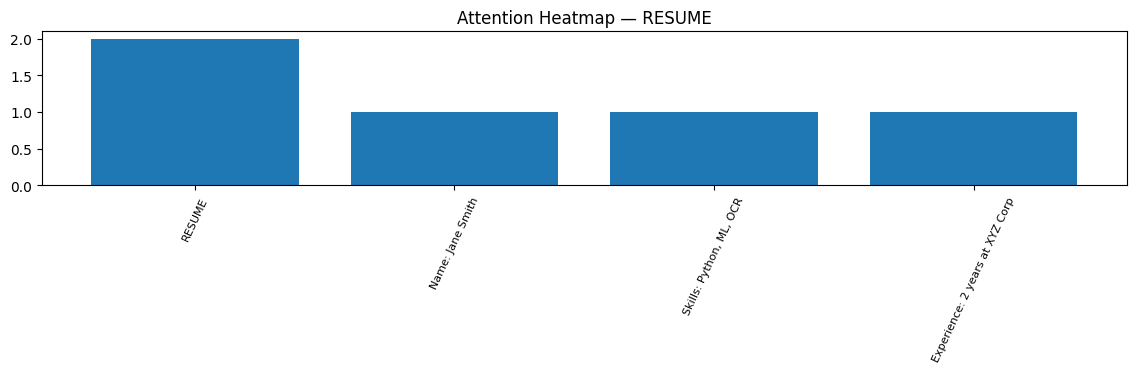

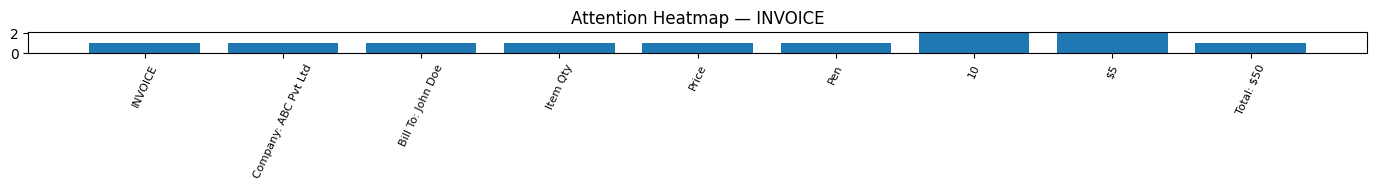

/tmp/ipython-input-3369711169.py:11: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


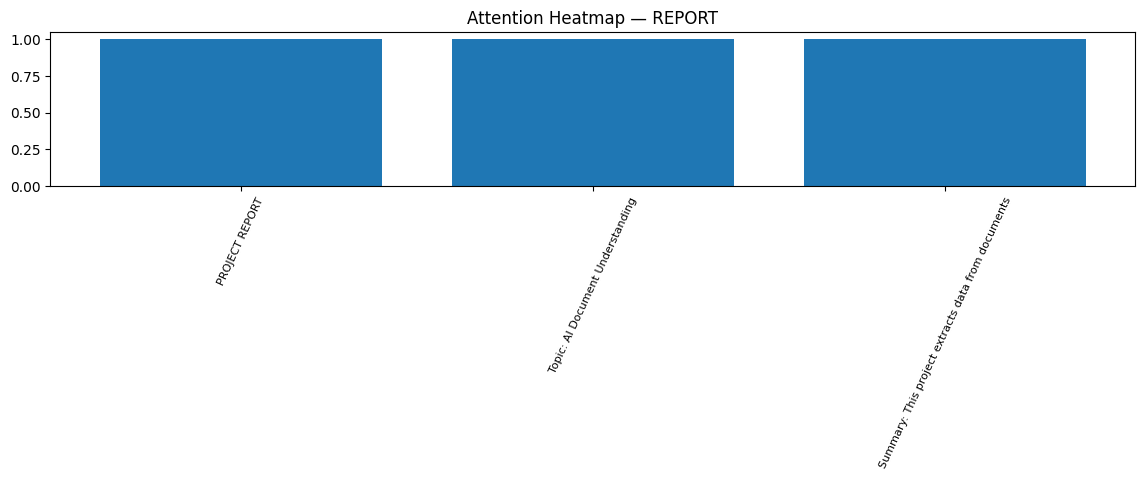

In [120]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_attention(words, tags, title):
    scores = [2 if tag != "O" else 1 for tag in tags]

    plt.figure(figsize=(14, 2))
    plt.bar(range(len(words)), scores)
    plt.xticks(range(len(words)), words, rotation=65, fontsize=8)
    plt.title(f"Attention Heatmap — {title}")
    plt.tight_layout()
    plt.show()

print("\n🔍 Generating Explainable Attention Maps...\n")
for item in layoutlm_data:
    visualize_attention(
        item["words"],
        item["ner_tags"],
        title=item["label"].upper()
    )


In [121]:
import json

def validate_invoice(invoice):
    if not invoice:
        return {"status": "Invalid - empty invoice"}

    issue_list = []

    if "items" in invoice:
        calc_total = 0
        for item in invoice["items"]:
            price = int(item["price"].replace("$", ""))
            qty = item["quantity"]
            calc_total += price * qty

        extracted_total = int(invoice["total"].replace("$", ""))

        if calc_total != extracted_total:
            issue_list.append(f"Total mismatch: calculated ${calc_total} vs extracted ${extracted_total}")

    return {
        "status": "Pass" if not issue_list else "Fail",
        "issues": issue_list
    }


def score_resume(resume):
    score = 0
    reasons = []

    if "skills" in resume:
        score += len(resume["skills"]) * 10
        reasons.append("More skills → better score")

    if "experience" in resume:
        exp_years = int(resume["experience"].split()[0])
        score += exp_years * 20
        reasons.append("More experience → higher score")

    ranking = "Strong" if score >= 50 else "Average" if score >= 30 else "Weak"

    return {"Score": score, "Rank": ranking, "Reasoning": reasons}


def check_report(report):
    missing = []

    for field in ["topic", "summary"]:
        if field not in report or not report[field]:
            missing.append(f"Missing {field}")

    return {
        "status": "Pass" if not missing else "Fail",
        "missing": missing
    }

reasoning_output = {
    "invoice_reasoning": validate_invoice(final_output["invoice"]),
    "resume_ranking": score_resume(final_output["resume"]),
    "report_validation": check_report(final_output["report"])
}

print("\n🤖 Reasoning Results:")
print(json.dumps(reasoning_output, indent=4))

with open("reasoning_output.json", "w") as f:
    json.dump(reasoning_output, f, indent=4)

print("\n Reasoning completed and saved to reasoning_output.json")



🤖 Reasoning Results:
{
    "invoice_reasoning": {
        "status": "Pass",
        "issues": []
    },
    "resume_ranking": {
        "Score": 70,
        "Rank": "Strong",
        "Reasoning": [
            "More skills \u2192 better score",
            "More experience \u2192 higher score"
        ]
    },
    "report_validation": {
        "status": "Pass",
        "missing": []
    }
}

 Reasoning completed and saved to reasoning_output.json


In [122]:
!pip install fastapi uvicorn python-multipart pillow nest_asyncio


In [123]:
%%writefile app.py
from fastapi import FastAPI, UploadFile, File
import uvicorn

app = FastAPI()

@app.get("/")
def home():
    return {"status": " FastAPI is running successfully!"}

@app.post("/upload")
async def upload_document(file: UploadFile = File(...)):
    content = await file.read()
    return {
        "filename": file.filename,
        "size": len(content),
        "message": "File uploaded successfully!"
    }


Overwriting app.py


In [124]:
from google.colab.output import eval_js
print(eval_js("google.colab.kernel.proxyPort(8000)"))


https://8000-m-s-3t9n8w0tl5tuk-c.us-west1-2.prod.colab.dev
